# SWYNEX Task 2 – Exploratory Data Analysis (EDA)

### Retail Store Sales Dataset

**Tools Used:** Python, Pandas, Matplotlib, Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
file_path = "SWYNEX_Task1_Data_Cleaning.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 12575
Columns: 13


In [3]:
print(df.columns.tolist())

['Transaction_id', 'Customer_id', 'Category', 'Item', 'Price_Per_Unit', 'Quantity', 'Total_Spent', 'Payment_Method', 'Payment_Method_Clean', 'Location', 'Transaction_Date', 'Discount_Applied', 'Price_Recovered']


In [4]:
df.head()

,Transaction_id,Customer_id,Category,Item,Price_Per_Unit,Quantity,Total_Spent,Payment_Method,Payment_Method_Clean,Location,Transaction_Date,Discount_Applied,Price_Recovered
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Digital Wallet,Online,2024-04-08,True,18.5
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Digital Wallet,Online,2023-07-23,True,29.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Credit Card,Online,2022-10-05,False,21.5
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Credit Card,Online,2022-05-07,False,27.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Digital Wallet,Online,2022-10-02,False,12.5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Transaction_id        12575 non-null  str           
 1   Customer_id           12575 non-null  str           
 2   Category              12575 non-null  str           
 3   Item                  12575 non-null  str           
 4   Price_Per_Unit        11966 non-null  float64       
 5   Quantity              11971 non-null  float64       
 6   Total_Spent           11971 non-null  float64       
 7   Payment_Method        12575 non-null  str           
 8   Payment_Method_Clean  12575 non-null  str           
 9   Location              12575 non-null  str           
 10  Transaction_Date      12575 non-null  datetime64[us]
 11  Discount_Applied      12575 non-null  bool          
 12  Price_Recovered       12575 non-null  float64       
dtypes: bool(1), datetime64[us](

In [6]:
df.describe()

,Price_Per_Unit,Quantity,Total_Spent,Transaction_Date,Price_Recovered
count,11966.000000,11971.000000,11971.000000,12575,12575.000000
mean,23.365912,5.536380,129.652577,2023-07-12 20:23:41.105367,23.369304
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00,5.000000
25%,14.000000,3.000000,51.000000,2022-09-30 00:00:00,14.000000
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00,23.000000
75%,33.500000,8.000000,192.000000,2024-04-24 00:00:00,33.500000
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00,41.000000
std,10.743519,2.857883,94.750697,NaN,10.748728


In [7]:
df["Category"].value_counts()

Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

In [8]:
category_sales = df.groupby("Category")["Total_Spent"].sum().sort_values(ascending=False)

category_sales

Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total_Spent, dtype: float64

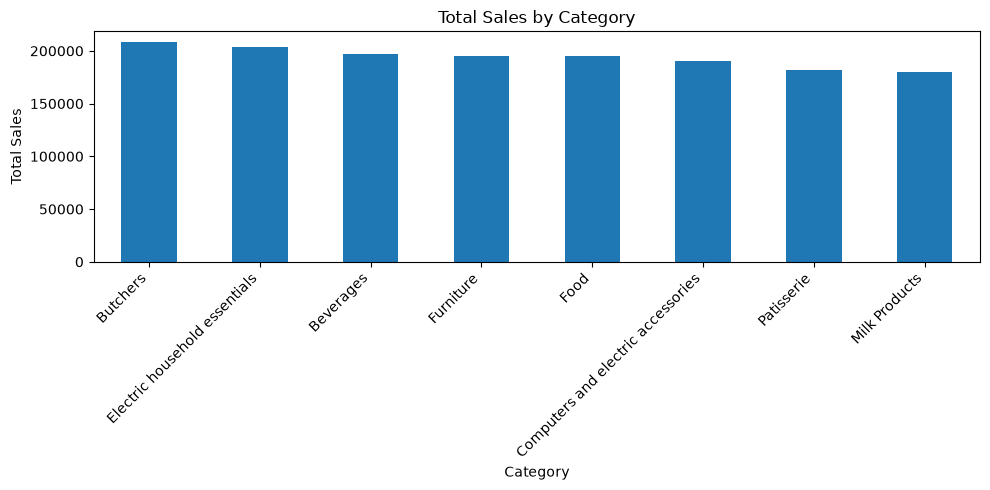

In [9]:
category_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
df["Payment_Method_Clean"].value_counts()

Payment_Method_Clean
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

In [11]:
payment_sales = df.groupby("Payment_Method_Clean")["Total_Spent"].sum().sort_values(ascending=False)

payment_sales

Payment_Method_Clean
Cash              537710.0
Digital Wallet    507279.0
Credit Card       507082.0
Name: Total_Spent, dtype: float64

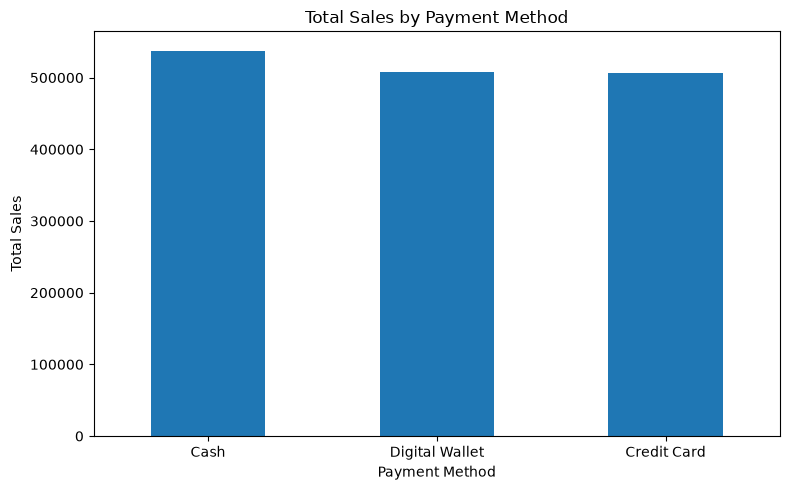

In [12]:
payment_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
df["Location"].value_counts()

Location
Online      6354
In-store    6221
Name: count, dtype: int64

In [14]:
location_sales = df.groupby("Location")["Total_Spent"].sum().sort_values(ascending=False)

location_sales

Location
Online      791401.0
In-store    760670.0
Name: Total_Spent, dtype: float64

In [15]:
location_avg_sales = df.groupby("Location")["Total_Spent"].mean()

location_avg_sales

Location
In-store    128.861596
Online      130.422050
Name: Total_Spent, dtype: float64

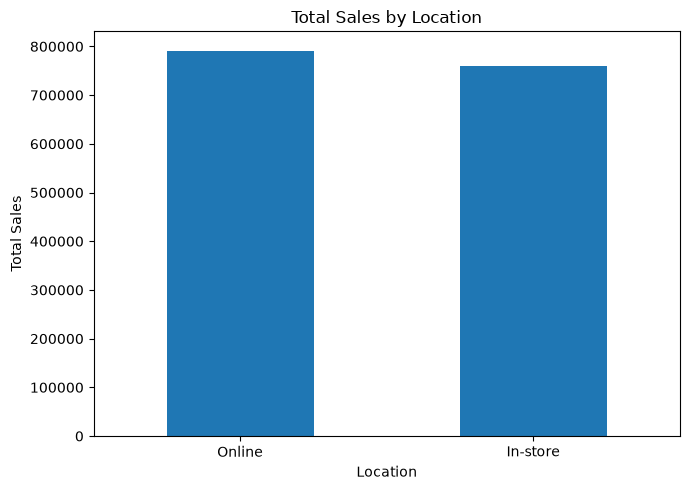

In [16]:
location_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Total Sales by Location")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
df["Month"] = df["Transaction_Date"].dt.to_period("M")

df[["Transaction_Date", "Month"]].head()

,Transaction_Date,Month
0,2024-04-08,2024-04
1,2023-07-23,2023-07
2,2022-10-05,2022-10
3,2022-05-07,2022-05
4,2022-10-02,2022-10


In [18]:
monthly_sales = df.groupby("Month")["Total_Spent"].sum()

monthly_sales

Month
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: Total_Spent, dtype: float64

In [19]:
jan_2025 = df[df["Transaction_Date"].dt.to_period("M") == "2025-01"]

print("First Date:", jan_2025["Transaction_Date"].min())
print("Last Date:", jan_2025["Transaction_Date"].max())
print("Number of Transactions:", len(jan_2025))

First Date: 2025-01-01 00:00:00
Last Date: 2025-01-18 00:00:00
Number of Transactions: 213


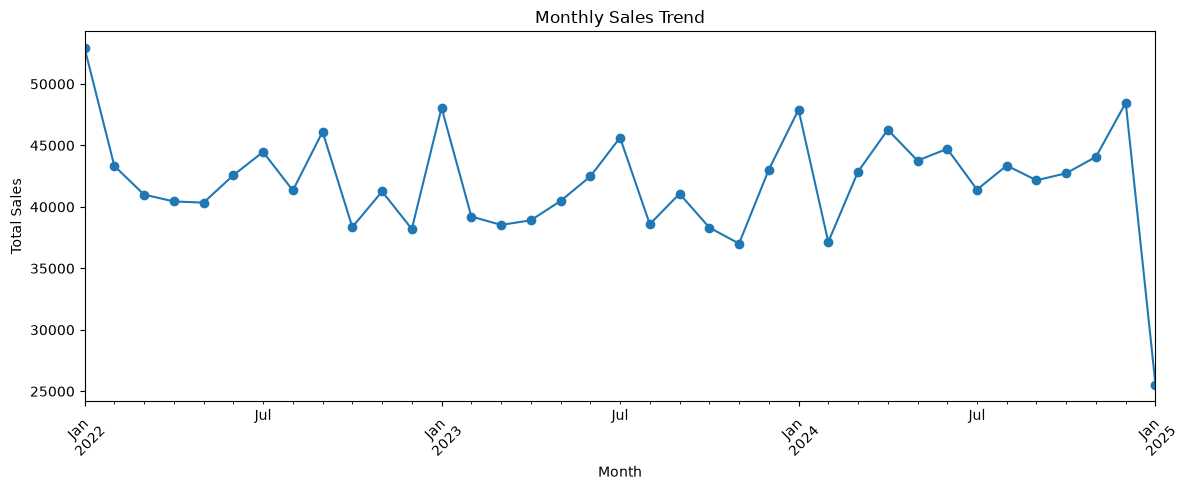

In [20]:
monthly_sales.plot(kind="line", figsize=(12, 5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Price_Per_Unit    609
Quantity          604
Total_Spent       604
dtype: int64

In [22]:
Q1 = df["Total_Spent"].quantile(0.25)
Q3 = df["Total_Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Total_Spent"] < lower_limit) |
    (df["Total_Spent"] > upper_limit)
]

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Lower Limit: -160.5
Upper Limit: 403.5
Number of Outliers: 60


In [23]:
outliers[[
    "Category",
    "Item",
    "Price_Per_Unit",
    "Quantity",
    "Total_Spent"
]].sort_values("Total_Spent", ascending=False).head(10)

,Category,Item,Price_Per_Unit,Quantity,Total_Spent
27,Furniture,Item_25_FUR,41.0,10.0,410.0
133,Furniture,Item_25_FUR,41.0,10.0,410.0
339,Food,Item_25_FOOD,41.0,10.0,410.0
869,Beverages,Item_25_BEV,41.0,10.0,410.0
1060,Furniture,Item_25_FUR,41.0,10.0,410.0
1088,Beverages,Item_25_BEV,41.0,10.0,410.0
1468,Butchers,Item_25_BUT,41.0,10.0,410.0
1505,Electric household essentials,Item_25_EHE,41.0,10.0,410.0
1568,Butchers,Item_25_BUT,41.0,10.0,410.0
1950,Furniture,Item_25_FUR,41.0,10.0,410.0


In [24]:
outliers["Category"].value_counts()

Category
Food                                  12
Beverages                             11
Butchers                              11
Electric household essentials         10
Furniture                              8
Milk Products                          3
Computers and electric accessories     3
Patisserie                             2
Name: count, dtype: int64

In [25]:
category_avg_sales = df.groupby("Category")["Total_Spent"].mean().sort_values(ascending=False)
category_avg_sales

Category
Butchers                              139.116310
Electric household essentials         134.441623
Beverages                             131.716243
Food                                  129.271400
Computers and electric accessories    129.107989
Furniture                             128.072131
Patisserie                            126.416031
Milk Products                         119.042961
Name: Total_Spent, dtype: float64

In [26]:
print("Average Transaction Value:", df["Total_Spent"].mean())
print("Median Transaction Value:", df["Total_Spent"].median())
print("Minimum Transaction Value:", df["Total_Spent"].min())
print("Maximum Transaction Value:", df["Total_Spent"].max())

Average Transaction Value: 129.6525770612313
Median Transaction Value: 108.5
Minimum Transaction Value: 5.0
Maximum Transaction Value: 410.0


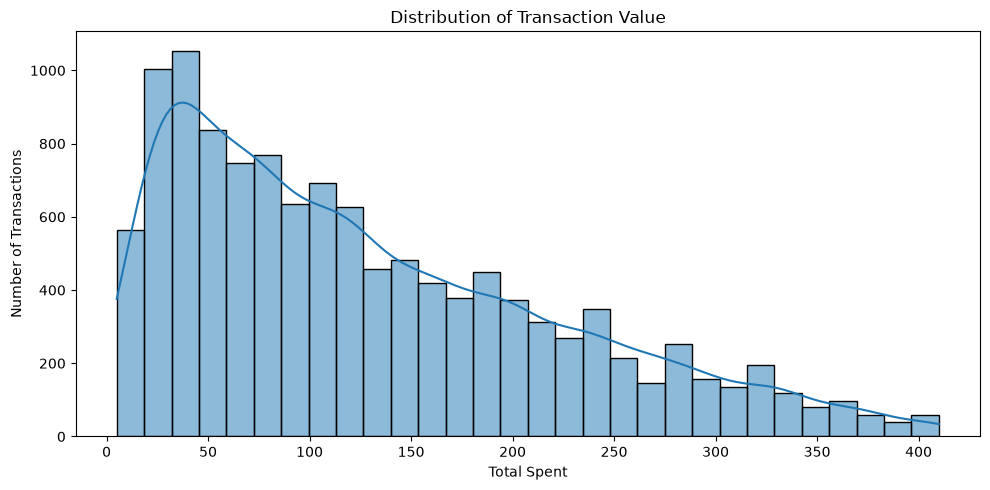

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Total_Spent"].dropna(), bins=30, kde=True)

plt.title("Distribution of Transaction Value")
plt.xlabel("Total Spent")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [28]:
category_summary = df.groupby("Category").agg(
    Transaction_Count=("Transaction_id", "count"),
    Total_Sales=("Total_Spent", "sum"),
    Average_Transaction=("Total_Spent", "mean")
).sort_values("Total_Sales", ascending=False)

category_summary

,Transaction_Count,Total_Sales,Average_Transaction
Category,,,
Butchers,1568,208118.0,139.116310
Electric household essentials,1591,203813.5,134.441623
Beverages,1567,197047.5,131.716243
Furniture,1591,195310.0,128.072131
Food,1588,194812.0,129.271400
Computers and electric accessories,1558,190692.5,129.107989
Patisserie,1528,182165.5,126.416031
Milk Products,1584,180112.0,119.042961


In [29]:
payment_summary = df.groupby("Payment_Method_Clean").agg(
    Transaction_Count=("Transaction_id", "count"),
    Total_Sales=("Total_Spent", "sum"),
    Average_Transaction=("Total_Spent", "mean")
).sort_values("Total_Sales", ascending=False)

payment_summary

,Transaction_Count,Total_Sales,Average_Transaction
Payment_Method_Clean,,,
Cash,4310,537710.0,131.052888
Digital Wallet,4144,507279.0,128.718346
Credit Card,4121,507082.0,129.127069


In [30]:
location_summary = df.groupby("Location").agg(
    Transaction_Count=("Transaction_id", "count"),
    Total_Sales=("Total_Spent", "sum"),
    Average_Transaction=("Total_Spent", "mean")
).sort_values("Total_Sales", ascending=False)

location_summary

,Transaction_Count,Total_Sales,Average_Transaction
Location,,,
Online,6354,791401.0,130.422050
In-store,6221,760670.0,128.861596


## Key Insights

1. **Butchers category generated the highest total sales** of ₹208,118 and also had the highest average transaction value of ₹139.12.

2. **Milk Products had a relatively high number of transactions (1,584)** but generated the lowest total sales of ₹180,112 and the lowest average transaction value of ₹119.04.

3. **Transaction volumes across categories were relatively balanced**, ranging from 1,528 to 1,591 transactions, but total sales varied across categories.

4. **Cash was the most used payment method**, with 4,310 transactions and total sales of ₹537,710. Digital Wallet and Credit Card sales were very close to each other.

5. **Online transactions were slightly higher than in-store transactions** (6,354 vs. 6,221), with online sales of ₹791,401 compared with ₹760,670 in-store.

6. **Monthly sales fluctuated throughout the period from January 2022 to January 2025.** January 2022 recorded the highest monthly sales of ₹52,911.50 among the months in the dataset.

7. **The dataset contains 60 high-value transactions identified as outliers** using the IQR method. The maximum transaction value was ₹410, and the highest-value records were internally consistent with price and quantity.

## Business Recommendations

1. **Review the Butchers category** to understand which products, quantities, or pricing factors are contributing to its higher average transaction value.

2. **Analyze Milk Products** to identify opportunities to increase the average transaction value, since it has a relatively high transaction count but the lowest average transaction value.

3. **Monitor payment method usage**, especially Cash, while tracking the adoption and sales contribution of Digital Wallet and Credit Card payments.

4. **Compare Online and In-store performance** regularly to understand differences in customer behavior, product mix, and transaction value.

5. **Investigate missing values** in Price_Per_Unit, Quantity, and Total_Spent before using the dataset for further analysis or predictive modeling.

6. **Review high-value transactions identified as outliers** to confirm that they represent genuine customer purchases and are not data-entry errors.

7. **Consider incomplete months when comparing monthly sales**, especially January 2025, which contains data only from January 1 to January 18.

In [32]:
print("EDA analysis completed successfully!")
print("Total records analyzed:", len(df))
print("Total columns in analysis dataset:", len(df.columns))

EDA analysis completed successfully!
Total records analyzed: 12575
Total columns in analysis dataset: 14
